# Handling Event Data
*by: Sebastiaan J. van Zelst*

Process Mining leverages event logs to generate knowledge about a process. A wide variety of information systems (e.g., SAP, ORACLE, and SalesForce) allow us to extract event logs similar to the example event logs used here for demonstration purposes. In fact, all of the examples shown in this and the following notebooks, as well as all of the algorithms implemented in PM4PY, assume that we have already extracted the event data and transformed it into an appropriate event log format. However, the core of PM4PY does not support any data extraction functions (see [Process Intelligence Solutions](https://processintelligence.solutions) to better understand the capabilities of our products and the scope of our portfolio).

To support interoperability between different process mining tools and libraries, two standard data formats are used to capture event logs: Comma Separated Value (CSV) files and eXtensible Event Stream (XES) files. In a CSV file, each row describes an event that has occurred, while the columns represent information associated with the events (e.g., the case in which the event occurred, the activity defining the event, a timestamp indicating the date and time of the event, and the resources involved). The XES file format is an XML-based format that allows us to describe process behavior. We will not go into detail about the XES file format (see the IEEE's [XES Standard](http://xes-standard.org) for an overview).

In this tutorial, we will use an often-used dummy example event log to explain the basic operations of process mining. The process we are considering is a simplified process related to customer complaint handling, taken from [Process Mining: Data Science in Action](https://www.springer.com/de/book/9783662498507) (van der Aalst 2016). The *a priori* model of the process looks as follows:

<figure>
  <img src="img/bpmn_running_example.png" alt="BPMN Process Model">
  <figcaption>Figure 1: BPMN-based process model describing the behavior of the simplified customer complaint handling process that we explore in this tutorial.</figcaption>
</figure>

## Importing CSV Files

We have prepared a small sample event log, containing behavior similar to the process model shown in Figure 1. You can find the raw sample event log [here](data/running_example.csv).

First, we load the event data and count how many cases are present in the event log. We also calculate the number of events and compute additional descriptives such as the average costs associated with customer complaint handling or the average amount of human resources involved in the process. Note that for all of this, from loading the event data to computing statistics, we are using a third-party library called pandas. We do this because pandas is the *de facto* standard whenever data is loaded from CSVs and manipulated in Python environments. Conveniently, any process mining algorithm implemented in PM4PY that takes an event log as input can also handle DataFrame objects from pandas.


In [30]:
import pandas as pd

# Load the event data
df = pd.read_csv('data/running_example.csv', sep=';')

# Display the DataFrame
df


,case_id,activity,timestamp,costs,org:resource
0,3,register request,2010-12-30 14:32:00+01:00,50,Pete
1,3,examine casually,2010-12-30 15:06:00+01:00,400,Mike
2,3,check ticket,2010-12-30 16:34:00+01:00,100,Ellen
3,3,decide,2011-01-06 09:18:00+01:00,200,Sara
4,3,reinitiate request,2011-01-06 12:18:00+01:00,200,Sara
5,3,examine thoroughly,2011-01-06 13:06:00+01:00,400,Sean
6,3,check ticket,2011-01-08 11:43:00+01:00,100,Pete
7,3,decide,2011-01-09 09:55:00+01:00,200,Sara
8,3,pay compensation,2011-01-15 10:45:00+01:00,200,Ellen
9,2,register request,2010-12-30 11:32:00+01:00,50,Mike


Let's examine the event log. The first line (i.e., row) specifies the name of each column (i.e., event attribute). Notice that in the data table described by the file, we have 5 columns, namely `case_id`, `activity`, `timestamp`, `costs`, and `org:resource`. The first column represents the case identifier, which allows us to identify which activity was logged in the context of which instance of the process. The second column is the name of the activity that was performed. The third column shows the date and time at which the activity was logged. In this example of event data, additional information is also present: the fourth column tracks the cost at the event/activity level; the fifth column tracks which (human) resource performed the activity.

Looking at the DataFrame shown above, we can see that rows 2-10 show the events recorded for case 3. We can also observe that the first activity performed was "register request", followed by "examine casually", "check ticket", "decide", "reinitiate request", "investigate thoroughly", "check ticket", "decide", and, finally, "pay compensation". This case therefore covers almost all the activities and mechanisms described by the BPMN-based model shown in Figure 1, including a loop triggered by re-initiation and the two forms of examination. Only the second end activity ("reject request") is not part of the instance, as only one end is possible per case – one result excludes the other and vice versa.

Let's examine some basic statistics of our log next, such as the total number of captured cases and the number of logged events.

In [31]:
# Compute number of cases
no_cases = len(df['case_id'].unique())

# Display the number of cases embedded in a brief statement
print(f'The event log contains {no_cases} cases.')


The event log contains 6 cases.


In [32]:
# Compute number of events
no_events = len(df)

# Display the number of events embedded in a brief statement
print(f'The event log contains {no_events} events.')


The event log contains 42 events.


In [33]:
# Calculate frequency of activities
activity_counts = df['activity'].value_counts()

# Display the frequency of activities
activity_counts


activity
decide                9
check ticket          9
examine casually      6
register request      6
reinitiate request    3
examine thoroughly    3
pay compensation      3
reject request        3
Name: count, dtype: int64

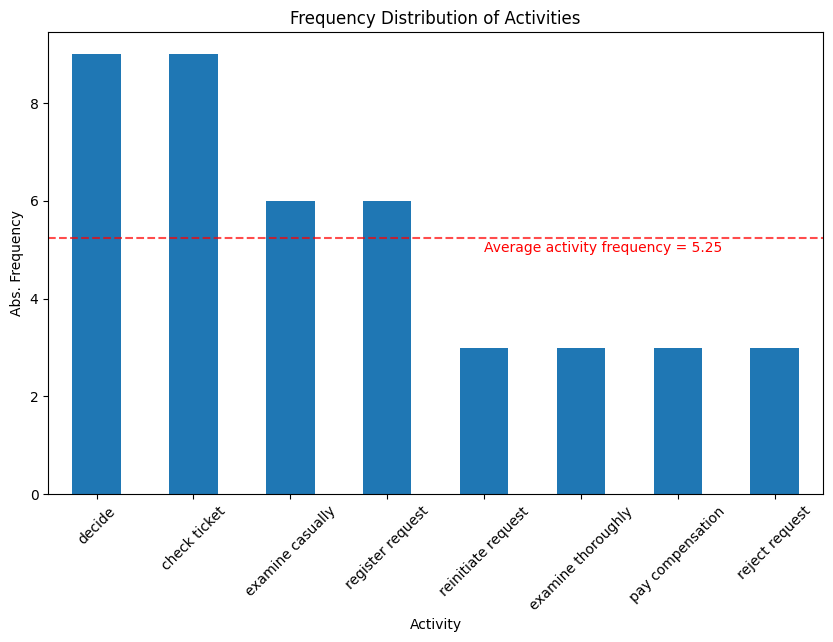

In [34]:
import matplotlib.pyplot as plt

def plot_activity_frequency(activity_counts, df):
    """
    Plots the frequency distribution of activities in the event log.
    
    Parameters:
    activity_counts (pd.Series): Series containing the frequency of each activity.
    df (pd.DataFrame): DataFrame containing the event log data.
    """
    plt.figure(figsize=(10, 6))
    activity_counts.plot(kind='bar')
    plt.title('Frequency Distribution of Activities')
    plt.xlabel('Activity')
    plt.ylabel('Abs. Frequency')
    plt.xticks(rotation=45)
    
    # Plot the average activity frequency line
    avg_frequency = activity_counts.mean()
    plt.axhline(y=avg_frequency, color='r', linestyle='--', alpha=0.7)
    
    # Annotate the average activity frequency
    plt.text(
        x=len(activity_counts) - 4,   
        y=avg_frequency - 0.3, 
        s=f'Average activity frequency = {avg_frequency:.2f}', 
        color='r'
    )
    
    plt.show()

# Call the function to plot the activity frequency
plot_activity_frequency(activity_counts, df)


In [35]:
def calculate_average_duration(df):
    """
    Calculates the average duration of cases in the event log.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing the event log data.
    
    Returns:
    tuple: Average duration in hours and days.
    """
    # Convert the timestamp column to datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Calculate the duration for each case
    df_duration = df.groupby('case_id').agg(
        start_time=('timestamp', 'min'), 
        end_time=('timestamp', 'max')
    )
    
    df_duration['duration'] = df_duration['end_time'] - df_duration['start_time']
    
    # Calculate the average duration
    average_duration = df_duration['duration'].mean()
    average_duration_hours = average_duration.total_seconds() / 3600  # 3,600 seconds in an hour
    average_duration_days = average_duration.total_seconds() / 86400  # 86,400 seconds in a day
    
    return average_duration_hours, average_duration_days

# Calculate and print the average duration
average_duration_hours, average_duration_days = calculate_average_duration(df)
print(f'Average process duration: {average_duration_hours:.2f} hours or {average_duration_days:.2f} days.')


Average process duration: 268.58 hours or 11.19 days.


In [36]:
def calculate_average_cost(df):
    """
    Calculates the average cost of a process instance.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing the event log data.
    
    Returns:
    float: Average cost of a process instance.
    """
    # Calculate the total cost for each case
    df_cost = df.groupby('case_id')['costs'].sum()
    
    # Calculate the average cost of a process instance
    average_cost = df_cost.mean()
    
    return average_cost

# Calculate and print the average cost
average_cost = calculate_average_cost(df)
print(f'Average process cost: {average_cost:.2f}')


Average process cost: 1400.00


In [37]:
def calculate_average_unique_employees(df):
    """
    Calculates the average number of unique employees involved per case.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing the event log data.
    
    Returns:
    float: Average number of unique employees per case.
    """
    # Calculate the number of unique employees per case
    unique_employees_per_case = df.groupby('case_id')['org:resource'].nunique()
    
    # Calculate the average number of unique employees per case
    average_unique_employees = unique_employees_per_case.mean()
    
    return average_unique_employees

# Calculate and print the average number of unique employees per case
average_unique_employees = calculate_average_unique_employees(df)
print(f'Average number of employees involved in the process: {average_unique_employees:.2f}')


Average number of employees involved in the process: 4.33


### Formatting Data Frames

Now that we have loaded our first event log, it is time to put some PM4PY into the mix.
PM4PY uses standardized column names to represent the *case identifier*, the *activity name* and the *timestamp*.
These are, respectively, `case:concept:name`, `concept:name` and `time:timestamp`.
Hence, to make PM4PY work with the provided csv file, we need to rename the `case_id`, `activity` and `timestamp` columns. PM4PY provides a dedicated utility function for this, `format_dataframe()`.

In [38]:
import pm4py

# Format the DataFrame for process mining with PM4Py
log = pm4py.format_dataframe(
    df,
    case_id='case_id', 
    activity_key='activity',
    timestamp_key='timestamp', 
    timest_format='%Y-%m-%d %H:%M:%S%z'
)

# Display the head of the log
log.head(n=10)


,case_id,activity,timestamp,costs,org:resource,case:concept:name,concept:name,time:timestamp,@@index,@@case_index
0,1,register request,2010-12-30 10:02:00+00:00,50,Pete,1,register request,2010-12-30 10:02:00+00:00,0,0
1,1,examine thoroughly,2010-12-31 09:06:00+00:00,400,Sue,1,examine thoroughly,2010-12-31 09:06:00+00:00,1,0
2,1,check ticket,2011-01-05 14:12:00+00:00,100,Mike,1,check ticket,2011-01-05 14:12:00+00:00,2,0
3,1,decide,2011-01-06 10:18:00+00:00,200,Sara,1,decide,2011-01-06 10:18:00+00:00,3,0
4,1,reject request,2011-01-07 13:24:00+00:00,200,Pete,1,reject request,2011-01-07 13:24:00+00:00,4,0
5,2,register request,2010-12-30 10:32:00+00:00,50,Mike,2,register request,2010-12-30 10:32:00+00:00,5,1
6,2,check ticket,2010-12-30 11:12:00+00:00,100,Mike,2,check ticket,2010-12-30 11:12:00+00:00,6,1
7,2,examine casually,2010-12-30 13:16:00+00:00,400,Sean,2,examine casually,2010-12-30 13:16:00+00:00,7,1
8,2,decide,2011-01-05 10:22:00+00:00,200,Sara,2,decide,2011-01-05 10:22:00+00:00,8,1
9,2,pay compensation,2011-01-08 11:05:00+00:00,200,Ellen,2,pay compensation,2011-01-08 11:05:00+00:00,9,1


Note that the original column names were not overwritten. Instead, the relevant columns were duplicated, and the DataFrame was extended horizontally to include these newly formatted columns.

Let us assume that we are not only interested in the number of events and cases, the average duration of the process, the financial costs associated with it, and the average number of employees involved in customer complaint handling. We also want to figure out what activities occur first and what activities occur last in the traces described by the event log.

PM4PY has specific built-in functions for this: `pm4py.get_start_activities()` and `pm4py.get_end_activities()`.

In [39]:
# Get the start activities of the process
initials_csv = pm4py.get_start_activities(log)

# Display the start activities
initials_csv


{'register request': 6}

In [40]:
# Get the end activities of the process
finals_csv = pm4py.get_end_activities(log)

# Display the end activities
finals_csv


{'reject request': 3, 'pay compensation': 3}

The `pm4py.get_start_activities()` and `pm4py.get_end_activities()` functions both return a dictionary containing the activities as keys and, as values, the number of observations (i.e., the number of traces in which they occur first or last) in the event log.

PM4PY leverages a built-in pandas function to automatically detect the timestamp format in the input data. However, pandas evaluates each timestamp value independently, which can occasionally lead to misinterpretations. For instance, a timestamp of `2020-01-18` (year, month, day) is a clear-cut case, while another value like `2020-02-01` might be misinterpreted as January 2 instead of February 1.

To address this issue, an additional parameter, `timest_format`, can be supplied to the `format_dataframe()` method. This parameter allows you to explicitly define the timestamp format using standard Python timestamp format codes. For example, in the event log used here, the correct timestamp format is `%Y-%m-%d %H:%M:%S%z`.

We strongly recommend always specifying the timestamp format when formatting a DataFrame for process mining to ensure consistent and accurate parsing, as demonstrated above.


## Importing XES Files

As mentioned in the tutorial introduction, event data can also be stored in XML-based XES files. XES files allow for the representation of a containment hierarchy: a log contains multiple traces, and each trace comprises several events. Moreover, objects such as logs, traces, and events can have attributes. This structure makes the storage more efficient, enabling attributes to be stored at the appropriate level.

For instance, suppose we only have information about the total cost of a case rather than the costs of individual events. In a CSV file, this would require either duplicating the information across rows (as data in CSVs typically corresponds to events) or explicitly indicating that certain columns are case-level attributes with unique values. In contrast, the XES standard offers a more intuitive and efficient way to represent such hierarchical information. To explore this further, you can access the raw XES file containing our event data by clicking [here](data/running_example.xes).

Importing an XES file is straightforward, thanks to PM4PY's dedicated `read_xes()` function. This function parses a given XES file and loads it as an Event Log object. Below is a code snippet demonstrating how to import an XES event log. Similar to the previous example where we imported a CSV file containing the event data, the script identifies activities that can start or end a trace.

In [41]:
# Import the running example event data in XES format
log_xes = pm4py.read_xes(
    'data/running_example.xes', 
    return_legacy_log_object=True  # Set to True to get EventLog instead of DataFrame
)

# Get and display start activities
initials_xes = pm4py.get_start_activities(log_xes)
initials_xes


parsing log, completed traces ::   0%|          | 0/6 [00:00<?, ?it/s]

{'register request': 6}

In [42]:
# Get and display end activities
finals_xes = pm4py.get_end_activities(log_xes)
finals_xes


{'pay compensation': 3, 'reject request': 3}

The start and end activities, along with their respective frequencies, match the results previously computed from the CSV-based DataFrame. For our tutorial, this alignment should suffice as proof of data consistency. We will therefore forgo re-calculating the other descriptive statistics already covered in the previous section.

## Exporting Event Data

Now we have seen how to import event data into PM4PY, let’s take a look at the opposite, that is, exporting event data. Exporting of event logs can be very useful, e.g., we might want to convert a CSV file into a XES file or we might want to filter out certain (noisy) cases and save the filtered event log. Like importing, exporting of event data is possible in two ways: exporting to CSV (using pandas) and exporting to XES. In the upcoming sections, we show how to perform the following export variants: 
- event log stored as a pandas DataFrame as CSV file
- pandas DataFrame as XES file
- PM4PY EventLog object as CSV file
- PM4PY EventLog object as XES file

### Storing a Pandas DataFrame as a CSV file

Storing an event log that is represented as a pandas dataframe is straightforward. We can directly use the ```to_csv()``` attribute of the pandas DataFrame object (see [API reference](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_csv.html) for comprehensive documentation). Consider the following example snippet of code, in which we show this functionality.

In [43]:
# Export the event log DataFrame to a CSV file
log.to_csv('running_example_DataFrame_exported_as_csv.csv', index=False)


### Storing a Pandas DataFrame as XES file

It is also possible to store a pandas data frame to a xes file. This is simply done by calling the ```pm4py.write_xes()```
function. You can pass the dataframe as an input parameter to the function, i.e., PM4PY handles the internal conversion
of the dataframe to an event log object prior to writing it to disk. Note that this construct only works if you have
formatted the data frame, i.e., as highlighted earlier in the importing CSV section.

In [44]:
# Export the event log DataFrame to a XES file
pm4py.write_xes(log, 'running_example_DataFrame_exported_as_xes.xes')


exporting log, completed traces ::   0%|          | 0/6 [00:00<?, ?it/s]

### Storing an EventLog object as CSV file

In some cases, we might want to store an event log object, e.g., obtained by importing a .xes file, as a csv file.
For example, certain (commercial) process mining tools only support csv importing. 
For this purpose, PM4PY offers conversion functionality that allows you to convert your event log object into a data frame,
which you can subsequently export using pandas.


In [45]:
# Convert EventLog object to DataFrame
df_xes = pm4py.convert_to_dataframe(log_xes)

# Export the event log DataFrame to a CSV file
df_xes.to_csv('running_example_xes_exported_as_csv.csv', index=False)


### Storing an EventLog Object as a XES File

Storing an event log object as a .xes file is rather straightforward. In PM4PY, the write_xes() method allows us to do so.
Consider the simple example script below in which we show an example of this functionality.

In [46]:
# Export the EventLog object to a XES file
pm4py.write_xes(log_xes, 'running_example_xes_exported_as_xes.xes')


exporting log, completed traces ::   0%|          | 0/6 [00:00<?, ?it/s]